MOS Training Notebook (SageMaker)

This notebook does **training + validation + final test**, and saves the best model to:

- `outputs_resnet18_mos/best_model.pth`

It is adapted from your original script and keeps the same core idea:

- **ResNet18 regression**
- output mapped to **1–5**
- **Phase 1:** freeze backbone, train FC only
- **Phase 2:** unfreeze `layer4 + fc`
- save the best checkpoint by **validation MAE**


# Install packages

In [1]:
# Optional: install packages if needed
%pip install -q torch torchvision pandas scikit-learn pillow tqdm matplotlib


Note: you may need to restart the kernel to use updated packages.


# Parameters settings

In [2]:
from pathlib import Path
import zipfile
import shutil
import pandas as pd

# =========================
# User-adjustable settings
# =========================
DATASET_ZIP = Path("dataset.zip")          # put dataset.zip in the same folder as this notebook
EXTRACT_DIR = Path("dataset_extracted")    # where zip will be extracted
OUTPUT_DIR = Path("outputs_resnet18_mos")  # saved model/logs will go here

# Training hyperparameters
RANDOM_SEED = 42
TRAIN_RATIO = 0.8
VAL_RATIO = 0.1
TEST_RATIO = 0.1

IMAGE_SIZE = 224
BATCH_SIZE = 16
NUM_WORKERS = 0      # safer in notebook/SageMaker
PIN_MEMORY = True

PHASE1_EPOCHS = 3    # train fc only
PHASE2_EPOCHS = 12   # unfreeze layer4 + fc
LR_PHASE1 = 3e-4
LR_PHASE2 = 1e-4
WEIGHT_DECAY = 1e-4
EARLY_STOPPING_PATIENCE = 5

TARGET_COL = "MOS"
CSV_NAME_HINT = "koniq10k_scores_and_distributions.csv"  # will prefer this name if found

# =========================
# Unzip dataset.zip
# =========================
if not DATASET_ZIP.exists():
    raise FileNotFoundError(f"dataset.zip not found: {DATASET_ZIP.resolve()}")

if EXTRACT_DIR.exists():
    print(f"Removing existing folder: {EXTRACT_DIR}")
    shutil.rmtree(EXTRACT_DIR)

EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(DATASET_ZIP, "r") as zf:
    zf.extractall(EXTRACT_DIR)

print(f"Extracted to: {EXTRACT_DIR.resolve()}")

# =========================
# Auto-find CSV and image directory
# =========================
all_csvs = list(EXTRACT_DIR.rglob("*.csv"))
if not all_csvs:
    raise FileNotFoundError("No CSV file found after extracting dataset.zip")

preferred_csvs = [p for p in all_csvs if p.name.lower() == CSV_NAME_HINT.lower()]
CSV_PATH = preferred_csvs[0] if preferred_csvs else all_csvs[0]

df_preview = pd.read_csv(CSV_PATH)
if "image_name" not in df_preview.columns:
    raise ValueError(f"CSV must contain 'image_name' column. Found columns: {list(df_preview.columns)}")
if TARGET_COL not in df_preview.columns:
    raise ValueError(f"CSV must contain '{TARGET_COL}' column. Found columns: {list(df_preview.columns)}")

sample_names = df_preview["image_name"].dropna().astype(str).head(200).tolist()

candidate_dirs = []
for p in EXTRACT_DIR.rglob("*"):
    if p.is_dir():
        score = sum((p / name).exists() for name in sample_names)
        if score > 0:
            candidate_dirs.append((score, p))

if not candidate_dirs:
    raise FileNotFoundError("Could not automatically find the image folder that matches image_name entries in the CSV.")

candidate_dirs.sort(key=lambda x: (-x[0], len(str(x[1]))))
IMAGE_DIR = candidate_dirs[0][1]

print(f"CSV_PATH : {CSV_PATH}")
print(f"IMAGE_DIR: {IMAGE_DIR}")
print(f"OUTPUT_DIR: {OUTPUT_DIR.resolve()}")
print(df_preview.head())


Removing existing folder: dataset_extracted
Extracted to: /home/sagemaker-user/dataset_extracted
CSV_PATH : dataset_extracted/koniq10k_scores_and_distributions.csv
IMAGE_DIR: dataset_extracted/512x384
OUTPUT_DIR: /home/sagemaker-user/outputs_resnet18_mos
        image_name  c1  c2  c3  c4  c5  c_total       MOS        SD  \
0  10004473376.jpg   0   0  25  73   7      105  3.828571  0.527278   
1  10007357496.jpg   0   3  45  47   1       96  3.479167  0.580003   
2  10007903636.jpg   1   0  20  73   2       96  3.781250  0.527220   
3  10009096245.jpg   0   0  21  75  13      109  3.926606  0.556218   
4    100117038.jpg   0   1  21  72   6      100  3.830000  0.532860   

   MOS_zscore  
0   77.383621  
1   68.728571  
2   78.628571  
3   77.243750  
4   75.112500  


# functions Define

In [3]:
import json
import math
import random
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torchvision.models import ResNet18_Weights

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def safe_pearsonr(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    if len(y_true) < 2:
        return float("nan")
    if np.std(y_true) == 0 or np.std(y_pred) == 0:
        return float("nan")
    return float(np.corrcoef(y_true, y_pred)[0, 1])

def safe_spearmanr(y_true, y_pred):
    y_true = pd.Series(y_true).rank(method="average").to_numpy()
    y_pred = pd.Series(y_pred).rank(method="average").to_numpy()
    return safe_pearsonr(y_true, y_pred)

def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=np.float32)
    y_pred = np.asarray(y_pred, dtype=np.float32)
    return {
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "rmse": float(math.sqrt(mean_squared_error(y_true, y_pred))),
        "plcc": safe_pearsonr(y_true, y_pred),
        "srcc": safe_spearmanr(y_true, y_pred),
    }

def create_stratify_bins(values, n_bins=10):
    values = pd.Series(values)
    try:
        return pd.qcut(values, q=min(n_bins, values.nunique()), labels=False, duplicates="drop")
    except Exception:
        return None

def save_json(data, path):
    path = Path(path)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(data, f, indent=2, ensure_ascii=False)

class KoniqDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True).copy()
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_path = Path(row["image_path"])
        image = Image.open(image_path).convert("RGB")
        if self.transform is not None:
            image = self.transform(image)

        target = torch.tensor(float(row[TARGET_COL]), dtype=torch.float32)
        image_name = row["image_name"]
        sd = float(row["SD"]) if "SD" in row and pd.notna(row["SD"]) else np.nan
        c_total = float(row["c_total"]) if "c_total" in row and pd.notna(row["c_total"]) else np.nan
        return image, target, image_name, sd, c_total

class ResNet18MOSRegressor(nn.Module):
    # Output is mapped to [1, 5] with sigmoid.
    def __init__(self):
        super().__init__()
        try:
            weights = ResNet18_Weights.DEFAULT
            self.backbone = models.resnet18(weights=weights)
            print("Loaded ImageNet pretrained ResNet18 weights.")
        except Exception as e:
            print(f"Could not load pretrained weights, using random init instead. Reason: {e}")
            self.backbone = models.resnet18(weights=None)

        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Dropout(p=0.2),
            nn.Linear(in_features, 1)
        )

    def forward(self, x):
        raw = self.backbone(x).squeeze(1)
        pred = 1.0 + 4.0 * torch.sigmoid(raw)
        return pred

    def freeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = False
        for p in self.backbone.fc.parameters():
            p.requires_grad = True

    def unfreeze_layer4_and_fc(self):
        for p in self.backbone.layer4.parameters():
            p.requires_grad = True
        for p in self.backbone.fc.parameters():
            p.requires_grad = True

def train_one_epoch(model, loader, optimizer, criterion, device, epoch, total_epochs):
    model.train()
    running_loss = 0.0
    all_targets, all_preds = [], []

    pbar = tqdm(loader, desc=f"Train [{epoch}/{total_epochs}]", ncols=120)
    for images, targets, _, _, _ in pbar:
        images = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        optimizer.zero_grad()
        preds = model(images)
        loss = criterion(preds, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        all_targets.extend(targets.detach().cpu().numpy().tolist())
        all_preds.extend(preds.detach().cpu().numpy().tolist())

        batch_mae = torch.mean(torch.abs(preds.detach() - targets)).item()
        pbar.set_postfix(loss=f"{loss.item():.4f}", batch_mae=f"{batch_mae:.4f}")

    metrics = compute_metrics(all_targets, all_preds)
    metrics["loss"] = float(running_loss / len(loader.dataset))
    return metrics

@torch.no_grad()
def evaluate(model, loader, criterion, device, epoch=None, total_epochs=None, split_name="Val"):
    model.eval()
    running_loss = 0.0
    all_targets, all_preds = [], []
    rows = []

    desc = split_name if epoch is None else f"{split_name} [{epoch}/{total_epochs}]"
    pbar = tqdm(loader, desc=desc, ncols=120)

    for images, targets, image_names, sds, c_totals in pbar:
        images = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        preds = model(images)
        loss = criterion(preds, targets)

        running_loss += loss.item() * images.size(0)
        preds_np = preds.detach().cpu().numpy()
        targets_np = targets.detach().cpu().numpy()

        all_targets.extend(targets_np.tolist())
        all_preds.extend(preds_np.tolist())

        batch_mae = np.mean(np.abs(preds_np - targets_np))
        pbar.set_postfix(loss=f"{loss.item():.4f}", batch_mae=f"{batch_mae:.4f}")

        for name, true_v, pred_v, sd, c_total in zip(image_names, targets_np, preds_np, sds, c_totals):
            rows.append({
                "image_name": name,
                "true_MOS": float(true_v),
                "pred_MOS": float(pred_v),
                "error": float(pred_v - true_v),
                "abs_error": float(abs(pred_v - true_v)),
                "SD": float(sd) if not pd.isna(sd) else np.nan,
                "c_total": float(c_total) if not pd.isna(c_total) else np.nan,
            })

    metrics = compute_metrics(all_targets, all_preds)
    metrics["loss"] = float(running_loss / len(loader.dataset))
    return metrics, pd.DataFrame(rows)

def build_optimizer(model, lr, weight_decay):
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    return torch.optim.AdamW(trainable_params, lr=lr, weight_decay=weight_decay)

def save_checkpoint(path, model, epoch, metrics, config):
    ckpt = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "metrics": metrics,
        "config": config,
    }
    torch.save(ckpt, path)


Device: cuda


MOS column distribution summary
----------------------------------------
Number of valid MOS values: 10073
Number of missing MOS values: 0

count    10073.000000
mean         3.161990
std          0.552202
min          1.096154
25%          2.830189
50%          3.281818
75%          3.585586
max          4.310000
Name: MOS, dtype: float64


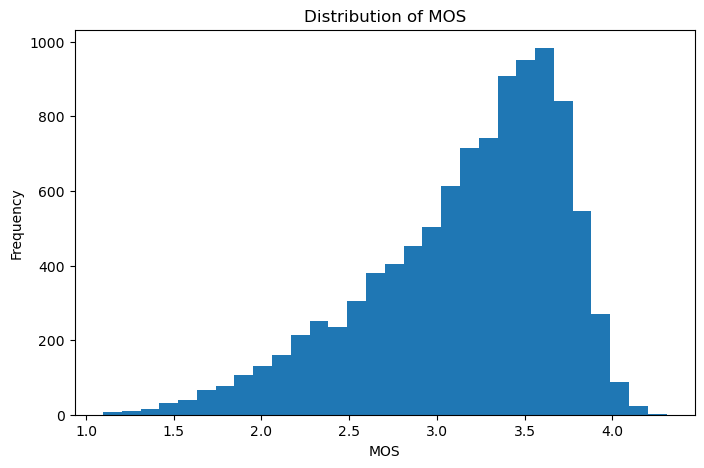

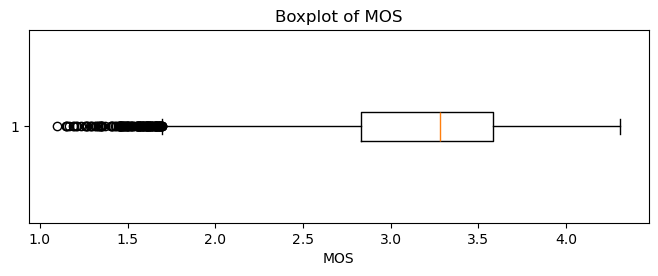

In [6]:
# MOS distribution summary
import matplotlib.pyplot as plt

# if df has already been read above, you can use it directly
# otherwise uncomment the next line:
# df = pd.read_csv(CSV_PATH)

mos = df_preview["MOS"].dropna()

print("MOS column distribution summary")
print("-" * 40)
print(f"Number of valid MOS values: {len(mos)}")
print(f"Number of missing MOS values: {df_preview['MOS'].isna().sum()}")
print()
print(mos.describe())

# Histogram
plt.figure(figsize=(8, 5))
plt.hist(mos, bins=30)
plt.xlabel("MOS")
plt.ylabel("Frequency")
plt.title("Distribution of MOS")
plt.show()

# Boxplot
plt.figure(figsize=(8, 2.5))
plt.boxplot(mos, vert=False)
plt.xlabel("MOS")
plt.title("Boxplot of MOS")
plt.show()

# Train the Model

In [4]:
seed_everything(RANDOM_SEED)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# -----------------------------
# Read CSV and build dataframe
# -----------------------------
df = pd.read_csv(CSV_PATH)

required_cols = ["image_name", TARGET_COL]
for col in required_cols:
    if col not in df.columns:
        raise ValueError(f"CSV is missing required column: {col}")

df = df.copy()
df[TARGET_COL] = pd.to_numeric(df[TARGET_COL], errors="coerce")
if "SD" in df.columns:
    df["SD"] = pd.to_numeric(df["SD"], errors="coerce")
if "c_total" in df.columns:
    df["c_total"] = pd.to_numeric(df["c_total"], errors="coerce")

df = df.dropna(subset=[TARGET_COL]).reset_index(drop=True)
df["image_path"] = df["image_name"].apply(lambda x: str(IMAGE_DIR / x))
df["exists"] = df["image_path"].apply(lambda x: Path(x).exists())

missing_count = int((~df["exists"]).sum())
if missing_count > 0:
    print(f"Warning: {missing_count} images listed in CSV were not found and will be skipped.")

df = df[df["exists"]].drop(columns=["exists"]).reset_index(drop=True)

if len(df) == 0:
    raise ValueError("No usable samples found. Please check your CSV and extracted image folder.")

print(f"Usable samples: {len(df)}")

# -----------------------------
# Train / val / test split
# -----------------------------
bins = create_stratify_bins(df[TARGET_COL], n_bins=10)

try:
    train_df, temp_df = train_test_split(
        df, test_size=(1.0 - TRAIN_RATIO), random_state=RANDOM_SEED, stratify=bins if bins is not None else None
    )
except Exception:
    train_df, temp_df = train_test_split(
        df, test_size=(1.0 - TRAIN_RATIO), random_state=RANDOM_SEED
    )

temp_bins = create_stratify_bins(temp_df[TARGET_COL], n_bins=10)
val_size_within_temp = VAL_RATIO / (VAL_RATIO + TEST_RATIO)

try:
    val_df, test_df = train_test_split(
        temp_df,
        test_size=(1.0 - val_size_within_temp),
        random_state=RANDOM_SEED,
        stratify=temp_bins if temp_bins is not None else None,
    )
except Exception:
    val_df, test_df = train_test_split(
        temp_df,
        test_size=(1.0 - val_size_within_temp),
        random_state=RANDOM_SEED,
    )

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

train_df.to_csv(OUTPUT_DIR / "train_split.csv", index=False)
val_df.to_csv(OUTPUT_DIR / "val_split.csv", index=False)
test_df.to_csv(OUTPUT_DIR / "test_split.csv", index=False)

# -----------------------------
# Transforms and loaders
# -----------------------------
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

train_dataset = KoniqDataset(train_df, transform=train_transform)
val_dataset = KoniqDataset(val_df, transform=eval_transform)
test_dataset = KoniqDataset(test_df, transform=eval_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=(PIN_MEMORY and DEVICE.type == "cuda"),
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(PIN_MEMORY and DEVICE.type == "cuda"),
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(PIN_MEMORY and DEVICE.type == "cuda"),
)

# -----------------------------
# Model / loss / config
# -----------------------------
model = ResNet18MOSRegressor().to(DEVICE)
criterion = nn.SmoothL1Loss()

total_epochs = PHASE1_EPOCHS + PHASE2_EPOCHS
best_val_mae = float("inf")
best_epoch = -1
no_improve_count = 0
logs = []

config = {
    "image_dir": str(IMAGE_DIR),
    "csv_path": str(CSV_PATH),
    "output_dir": str(OUTPUT_DIR),
    "random_seed": RANDOM_SEED,
    "train_ratio": TRAIN_RATIO,
    "val_ratio": VAL_RATIO,
    "test_ratio": TEST_RATIO,
    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "phase1_epochs": PHASE1_EPOCHS,
    "phase2_epochs": PHASE2_EPOCHS,
    "lr_phase1": LR_PHASE1,
    "lr_phase2": LR_PHASE2,
    "weight_decay": WEIGHT_DECAY,
    "early_stopping_patience": EARLY_STOPPING_PATIENCE,
    "target_col": TARGET_COL,
    "model_name": "resnet18_mos_regression",
    "device": str(DEVICE),
}
save_json(config, OUTPUT_DIR / "config.json")

# =====================================================
# Phase 1: freeze backbone, train fc only
# =====================================================
print("\n" + "=" * 80)
print("Phase 1: Freeze backbone, train fc only")
print("=" * 80)

model.freeze_backbone()
optimizer = build_optimizer(model, lr=LR_PHASE1, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)

for epoch in range(1, PHASE1_EPOCHS + 1):
    train_metrics = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE, epoch, total_epochs)
    val_metrics, _ = evaluate(model, val_loader, criterion, DEVICE, epoch, total_epochs, split_name="Val")
    scheduler.step(val_metrics["mae"])

    row = {
        "epoch": epoch,
        "phase": 1,
        "lr": optimizer.param_groups[0]["lr"],
        "train_loss": train_metrics["loss"],
        "train_mae": train_metrics["mae"],
        "train_rmse": train_metrics["rmse"],
        "train_plcc": train_metrics["plcc"],
        "train_srcc": train_metrics["srcc"],
        "val_loss": val_metrics["loss"],
        "val_mae": val_metrics["mae"],
        "val_rmse": val_metrics["rmse"],
        "val_plcc": val_metrics["plcc"],
        "val_srcc": val_metrics["srcc"],
    }
    logs.append(row)

    print(
        f"[Epoch {epoch}/{total_epochs}] "
        f"train_loss={train_metrics['loss']:.4f}, train_mae={train_metrics['mae']:.4f}, "
        f"val_loss={val_metrics['loss']:.4f}, val_mae={val_metrics['mae']:.4f}, "
        f"val_rmse={val_metrics['rmse']:.4f}, val_plcc={val_metrics['plcc']:.4f}, val_srcc={val_metrics['srcc']:.4f}"
    )

    if val_metrics["mae"] < best_val_mae:
        best_val_mae = val_metrics["mae"]
        best_epoch = epoch
        no_improve_count = 0
        save_checkpoint(OUTPUT_DIR / "best_model.pth", model, epoch, val_metrics, config)
        print(f"  -> Best model updated at epoch {epoch} (val_mae={best_val_mae:.4f})")
    else:
        no_improve_count += 1

# =====================================================
# Phase 2: unfreeze layer4 + fc
# =====================================================
print("\n" + "=" * 80)
print("Phase 2: Unfreeze layer4 + fc")
print("=" * 80)

model.unfreeze_layer4_and_fc()
optimizer = build_optimizer(model, lr=LR_PHASE2, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)

for phase2_idx in range(1, PHASE2_EPOCHS + 1):
    epoch = PHASE1_EPOCHS + phase2_idx

    train_metrics = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE, epoch, total_epochs)
    val_metrics, _ = evaluate(model, val_loader, criterion, DEVICE, epoch, total_epochs, split_name="Val")
    scheduler.step(val_metrics["mae"])

    row = {
        "epoch": epoch,
        "phase": 2,
        "lr": optimizer.param_groups[0]["lr"],
        "train_loss": train_metrics["loss"],
        "train_mae": train_metrics["mae"],
        "train_rmse": train_metrics["rmse"],
        "train_plcc": train_metrics["plcc"],
        "train_srcc": train_metrics["srcc"],
        "val_loss": val_metrics["loss"],
        "val_mae": val_metrics["mae"],
        "val_rmse": val_metrics["rmse"],
        "val_plcc": val_metrics["plcc"],
        "val_srcc": val_metrics["srcc"],
    }
    logs.append(row)

    print(
        f"[Epoch {epoch}/{total_epochs}] "
        f"train_loss={train_metrics['loss']:.4f}, train_mae={train_metrics['mae']:.4f}, "
        f"val_loss={val_metrics['loss']:.4f}, val_mae={val_metrics['mae']:.4f}, "
        f"val_rmse={val_metrics['rmse']:.4f}, val_plcc={val_metrics['plcc']:.4f}, val_srcc={val_metrics['srcc']:.4f}"
    )

    if val_metrics["mae"] < best_val_mae:
        best_val_mae = val_metrics["mae"]
        best_epoch = epoch
        no_improve_count = 0
        save_checkpoint(OUTPUT_DIR / "best_model.pth", model, epoch, val_metrics, config)
        print(f"  -> Best model updated at epoch {epoch} (val_mae={best_val_mae:.4f})")
    else:
        no_improve_count += 1

    if no_improve_count >= EARLY_STOPPING_PATIENCE:
        print(f"Early stopping triggered at epoch {epoch}.")
        break

save_checkpoint(OUTPUT_DIR / "last_model.pth", model, epoch, val_metrics, config)

log_df = pd.DataFrame(logs)
log_df.to_csv(OUTPUT_DIR / "training_log.csv", index=False)

# -----------------------------
# Final test using best model
# -----------------------------
best_ckpt = torch.load(OUTPUT_DIR / "best_model.pth", map_location=DEVICE)
model.load_state_dict(best_ckpt["model_state_dict"])
print("\n" + "=" * 80)
print(f"Loaded best model from epoch {best_ckpt['epoch']} for final testing.")
print("=" * 80)

test_metrics, test_pred_df = evaluate(model, test_loader, criterion, DEVICE, split_name="Test")
test_pred_df.to_csv(OUTPUT_DIR / "test_predictions.csv", index=False)

summary = {
    "best_epoch": int(best_ckpt["epoch"]),
    "best_val_mae": float(best_val_mae),
    "test_loss": float(test_metrics["loss"]),
    "test_mae": float(test_metrics["mae"]),
    "test_rmse": float(test_metrics["rmse"]),
    "test_plcc": float(test_metrics["plcc"]) if not np.isnan(test_metrics["plcc"]) else None,
    "test_srcc": float(test_metrics["srcc"]) if not np.isnan(test_metrics["srcc"]) else None,
}
save_json(summary, OUTPUT_DIR / "test_summary.json")

print("\n" + "=" * 80)
print("Final Test Results")
print("=" * 80)
print(f"Best epoch : {summary['best_epoch']}")
print(f"Best val MAE: {summary['best_val_mae']:.4f}")
print(f"Test Loss  : {summary['test_loss']:.4f}")
print(f"Test MAE   : {summary['test_mae']:.4f}")
print(f"Test RMSE  : {summary['test_rmse']:.4f}")
print(f"Test PLCC  : {summary['test_plcc']}")
print(f"Test SRCC  : {summary['test_srcc']}")
print("=" * 80)
print(f"All outputs saved to: {OUTPUT_DIR.resolve()}")

display(log_df.tail())
display(pd.DataFrame([summary]))


Usable samples: 10073
Train: 8058 | Val: 1007 | Test: 1008
Loaded ImageNet pretrained ResNet18 weights.

Phase 1: Freeze backbone, train fc only


Val [1/15]: 100%|████████████████████████████████████████| 63/63 [00:05<00:00, 12.11it/s, batch_mae=0.3980, loss=0.1278]


[Epoch 1/15] train_loss=0.1559, train_mae=0.4467, val_loss=0.1062, val_mae=0.3492, val_rmse=0.4687, val_plcc=0.6066, val_srcc=0.5564
  -> Best model updated at epoch 1 (val_mae=0.3492)


Val [2/15]: 100%|████████████████████████████████████████| 63/63 [00:05<00:00, 11.00it/s, batch_mae=0.4155, loss=0.1165]


[Epoch 2/15] train_loss=0.1136, train_mae=0.3758, val_loss=0.0874, val_mae=0.3285, val_rmse=0.4218, val_plcc=0.6633, val_srcc=0.6197
  -> Best model updated at epoch 2 (val_mae=0.3285)


...

[Epoch 15/15] train_loss=0.0210, train_mae=0.1611, val_loss=0.0414, val_mae=0.2228, val_rmse=0.2885, val_plcc=0.8564, val_srcc=0.8234

Loaded best model from epoch 14 for final testing.


Test: 100%|██████████████████████████████████████████████| 63/63 [00:05<00:00, 11.35it/s, batch_mae=0.1371, loss=0.0148]


Final Test Results
Best epoch : 14
Best val MAE: 0.2198
Test Loss  : 0.0370
Test MAE   : 0.2108
Test RMSE  : 0.2720
Test PLCC  : 0.8694451296065425
Test SRCC  : 0.8338925134064342
All outputs saved to: /home/sagemaker-user/outputs_resnet18_mos


,epoch,phase,lr,train_loss,train_mae,train_rmse,train_plcc,train_srcc,val_loss,val_mae,val_rmse,val_plcc,val_srcc
10,11,2,0.00010,0.028503,0.188001,0.238762,0.901818,0.871361,0.042610,0.228426,0.292066,0.854883,0.819045
11,12,2,0.00010,0.027658,0.184775,0.235218,0.904828,0.877343,0.043051,0.225826,0.293685,0.860666,0.825362
12,13,2,0.00005,0.027569,0.183857,0.234860,0.905109,0.877079,0.042166,0.223525,0.290956,0.859464,0.832627
13,14,2,0.00005,0.022487,0.165654,0.212073,0.923296,0.901607,0.040285,0.219777,0.284356,0.861314,0.827559
14,15,2,0.00005,0.021040,0.161137,0.205134,0.928378,0.908310,0.041424,0.222778,0.288493,0.856434,0.823358


,best_epoch,best_val_mae,test_loss,test_mae,test_rmse,test_plcc,test_srcc
0,14,0.219777,0.036977,0.210756,0.271991,0.869445,0.833893
